In [2]:
# Main code
import argparse
import copy
import time

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# ================= Basic modules =================
class Norm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.norm = nn.LayerNorm(d_model, eps=eps)

    def forward(self, x):
        return self.norm(x)

class PositionalEncoder(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout)
        )
        self.norm1 = Norm(d_model)
        self.norm2 = Norm(d_model)

    def forward(self, x, mask=None):
        attn_out, _ = self.attn(x, x, x, key_padding_mask=mask)
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)
        return x

def get_clones(module, N):
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

# ================= Transformer Encoder =================
class Encoder(nn.Module):
    def __init__(self, in_dim, d_model, N, heads, dropout):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, d_model)
        self.pe = PositionalEncoder(d_model, dropout)
        self.layers = get_clones(EncoderLayer(d_model, heads, dropout), N)
        self.norm = Norm(d_model)

    def forward(self, src, mask=None):
        x = self.input_proj(src)
        x = self.pe(x)
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

# ================= Encoder-Only Transformer =================
class EncoderOnlyTransformer(nn.Module):
    def __init__(self, d_model, N, heads, dropout, src_dim=4, out_dim=2):
        super().__init__()
        self.encoder = Encoder(
            in_dim=src_dim,
            d_model=d_model,
            N=N,
            heads=heads,
            dropout=dropout
        )
        # Add one hidden layer to the output head to improve nonlinear mapping
        self.out = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, out_dim)
        )

    def forward(self, src, mask=None):
        """
        src: (batch, seq_len, in_dim)
        return: (batch, seq_len, out_dim)
        """
        x = self.encoder(src, mask)
        return self.out(x)

# ================= Model initialization function =================
def get_model(opt):
    model = EncoderOnlyTransformer(
        d_model=opt.d_model,
        N=opt.n_layers,
        heads=opt.heads,
        dropout=opt.dropout,
        src_dim=opt.src_dim if hasattr(opt, 'src_dim') else 4,
        out_dim=opt.out_dim if hasattr(opt, 'out_dim') else 2
    ).to(opt.device)

    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

    return model


In [ ]:
# ===== Cell 1: Load model + denormalized RMSE calculation =====
import argparse
import numpy as np
import torch

# 1) Config + model
parser = argparse.ArgumentParser()
parser.add_argument('-epochs', type=int, default=300)
parser.add_argument('-d_model', type=int, default=192)
parser.add_argument('-n_layers', type=int, default=3)
parser.add_argument('-heads', type=int, default=8)
parser.add_argument('-dropout', type=float, default=0.03)
parser.add_argument('-batchsize', type=int, default=32)
parser.add_argument('-lr', type=float, default=3e-4)
parser.add_argument('-no_cuda', action='store_true')

# StepLR parameters for the first phase
parser.add_argument('-lr_step', type=int, default=50)
parser.add_argument('-lr_gamma', type=float, default=0.9)

# Parameters for switching to cosine annealing
parser.add_argument('-switch_epoch', type=int, default=100)
parser.add_argument('-eta_min', type=float, default=1e-5)

opt = parser.parse_args(args=[])
opt.device = 'cuda' if (not opt.no_cuda and torch.cuda.is_available()) else 'cpu'

model = get_model(opt)
state_dict = torch.load('model_192_3_8_32_51w_gui.pth', map_location=opt.device)
model.load_state_dict(state_dict)
model.eval()

# 2) Load + preprocess data
X_all = np.load('X_all.npy')   # Raw physical values
Y_all = np.load('Y_all.npy')   # Raw physical values

# Ground truth in physical space: (N, C, L) -> (N, L, C)
Y_phys = np.transpose(Y_all, (0, 2, 1))

X_log = np.log(X_all)
Y_log = np.log(Y_all)

X_log_min, X_log_max = X_log.min(), X_log.max()
Y_log_min, Y_log_max = Y_log.min(), Y_log.max()

X_norm = (X_log - X_log_min) / (X_log_max - X_log_min)
Y_norm = (Y_log - Y_log_min) / (Y_log_max - Y_log_min)

# (N, C, L) -> (N, L, C)
X_norm = np.transpose(X_norm, (0, 2, 1))
Y_norm = np.transpose(Y_norm, (0, 2, 1))

X_tensor = torch.tensor(X_norm, dtype=torch.float32, device=opt.device)

group_size = 64
num_groups = 8000
need_rows = num_groups * group_size

if X_tensor.shape[0] < need_rows or Y_phys.shape[0] < need_rows:
    raise ValueError(f'Not enough rows: need at least {need_rows}.')

def log_minmax_denorm_torch(x_norm, log_min, log_max):
    return torch.exp(x_norm * (log_max - log_min) + log_min)

def add_gaussian_noise(x: torch.Tensor, noise_percent: float) -> torch.Tensor:
    if noise_percent <= 0:
        return x
    ratio = float(noise_percent) / 100.0
    x_noisy = x + ratio * torch.randn_like(x)
    return torch.clamp(x_noisy, 0.0, 1.0)

def compute_group_rmse(noise_percent: float = 0.0, seed: int = 2026):
    if noise_percent > 0:
        torch.manual_seed(seed)
        np.random.seed(seed)

    rmse_total = np.empty(num_groups, dtype=np.float64)
    rmse_xx = np.empty(num_groups, dtype=np.float64)
    rmse_yy = np.empty(num_groups, dtype=np.float64)

    for g in range(num_groups):
        s = g * group_size
        e = s + group_size

        T = X_tensor[s:e]       # Normalized input
        TT = Y_phys[s:e]        # Ground truth in physical space

        T_in = add_gaussian_noise(T, noise_percent)

        with torch.no_grad():
            pred_norm = model(T_in)

        # Denormalize predictions back to physical space
        log_min = torch.tensor(Y_log_min, dtype=torch.float32, device=pred_norm.device)
        log_max = torch.tensor(Y_log_max, dtype=torch.float32, device=pred_norm.device)
        pred_phys = log_minmax_denorm_torch(pred_norm, log_min, log_max)

        x_p = pred_phys[:, :, 0].detach().cpu().numpy()
        y_p = pred_phys[:, :, 1].detach().cpu().numpy()
        x_t = TT[:, :, 0]
        y_t = TT[:, :, 1]

        mse_xx = np.mean((x_p - x_t) ** 2)
        mse_yy = np.mean((y_p - y_t) ** 2)

        rmse_xx[g] = np.sqrt(mse_xx)
        rmse_yy[g] = np.sqrt(mse_yy)
        rmse_total[g] = np.sqrt((mse_xx + mse_yy) / 2.0)

    return {
        'rmse_total': rmse_total,
        'rmse_xx': rmse_xx,
        'rmse_yy': rmse_yy
    }

# Remove scenarios as needed
scenario_cfg = [
    ('clean', 0.0, 'No noise (0%)'),
    ('noise_1pct', 1.0, 'With noise (1%)'),
    ('noise_3pct', 3.0, 'With noise (3%)'),
    ('noise_5pct', 5.0, 'With noise (5%)'),
    ('noise_10pct', 10.0, 'With noise (10%)'),
]

all_group_rmse = {}
for i, (key, pct, _) in enumerate(scenario_cfg):
    all_group_rmse[key] = compute_group_rmse(noise_percent=pct, seed=2026 + i)

# Keep variable names compatible with later code (clean scenario)
group_rmse = all_group_rmse['clean']['rmse_total']


In [ ]:
# ===== Cell 2: Sort and print by denormalized RMSE =====
import numpy as np

n_show = 5

def get_rank_indices(values: np.ndarray, n_show: int = 5):
    sorted_idx = np.argsort(values)
    best_idx = sorted_idx[:n_show]
    mid_start = (len(values) - n_show) // 2
    mid_idx = sorted_idx[mid_start:mid_start + n_show]
    worst_idx = sorted_idx[-n_show:]
    return best_idx, mid_idx, worst_idx

def print_group_rank_table(rmse_pack: dict, title: str, n_show: int = 5):
    total = rmse_pack['rmse_total']
    xx = rmse_pack['rmse_xx']
    yy = rmse_pack['rmse_yy']

    best_idx, mid_idx, worst_idx = get_rank_indices(total, n_show)

    print("\n" + "=" * 96)
    print(title)
    print("=" * 96)

    def _print_block(block_name: str, idx_list: np.ndarray):
        print(f"\n[{block_name}]")
        print(f"{'Rank':>4} | {'Group':>8} | {'RMSE_total':>14} | {'RMSE_xx':>14} | {'RMSE_yy':>14}")
        print("-" * 70)
        for r, idx in enumerate(idx_list, 1):
            print(f"{r:>4} | {idx:>8d} | {total[idx]:>14.6f} | {xx[idx]:>14.6f} | {yy[idx]:>14.6f}")

    _print_block("Best top 5", best_idx)
    _print_block("Middle top 5", mid_idx)
    _print_block("Worst top 5", worst_idx)

# Single-group ranking for each noise scenario
for key, _, label in scenario_cfg:
    print_group_rank_table(
        all_group_rmse[key],
        title=f"{label} - Single-sample RMSE ranking (after denormalization)",
        n_show=n_show
    )

# Paired ranking; keep the original logic: clean scenario uses i <-> i+4000
pair_offset = 4000
num_pairs = 4000

clean_total = all_group_rmse['clean']['rmse_total']
clean_xx = all_group_rmse['clean']['rmse_xx']
clean_yy = all_group_rmse['clean']['rmse_yy']

if len(clean_total) < pair_offset + num_pairs:
    raise ValueError(f'length is insufficient for pairing: {len(clean_total)}')

a_total = clean_total[:num_pairs]
b_total = clean_total[pair_offset:pair_offset + num_pairs]
pair_total = 0.5 * (a_total + b_total)

a_xx = clean_xx[:num_pairs]
b_xx = clean_xx[pair_offset:pair_offset + num_pairs]
pair_xx = 0.5 * (a_xx + b_xx)

a_yy = clean_yy[:num_pairs]
b_yy = clean_yy[pair_offset:pair_offset + num_pairs]
pair_yy = 0.5 * (a_yy + b_yy)

sorted_pair_idx = np.argsort(pair_total)
best_pair_idx = sorted_pair_idx[:n_show]
mid_pair_start = (len(pair_total) - n_show) // 2
mid_pair_idx = sorted_pair_idx[mid_pair_start:mid_pair_start + n_show]
worst_pair_idx = sorted_pair_idx[-n_show:]

print("\n" + "=" * 110)
print("no (0%) ")
print("=" * 110)

def print_pair_block(title: str, idx_list: np.ndarray):
    print(f"\n[{title}]")
    print(f"{'Rank':>4} | {'Pair(i,j)':>15} | {'Pair_RMSE':>12} | {'Pair_RMSE_xx':>14} | {'Pair_RMSE_yy':>14}")
    print("-" * 78)
    for r, i in enumerate(idx_list, 1):
        j = i + pair_offset
        print(
            f"{r:>4} | ({i:>4d},{j:>4d})      | "
            f"{pair_total[i]:>12.6f} | {pair_xx[i]:>14.6f} | {pair_yy[i]:>14.6f}"
        )




Plot #1: num=253, right_noise_pct=0%


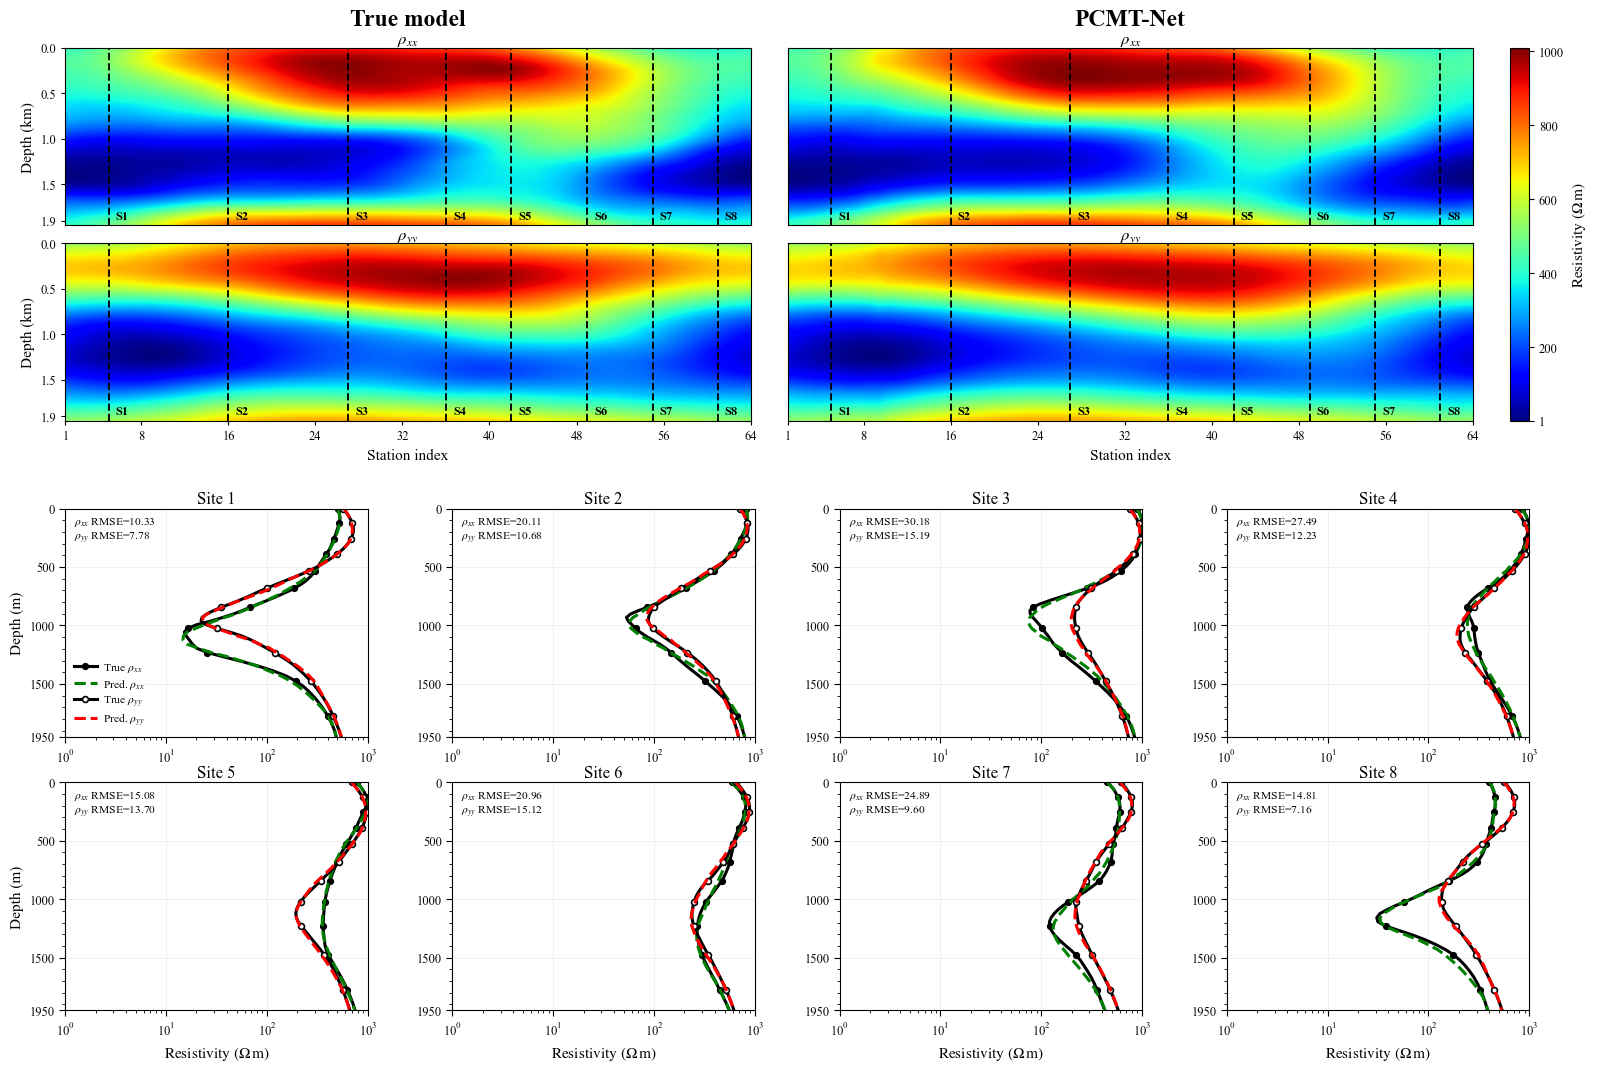

Plot #2: num=4253, right_noise_pct=0% (S1-S4 only)


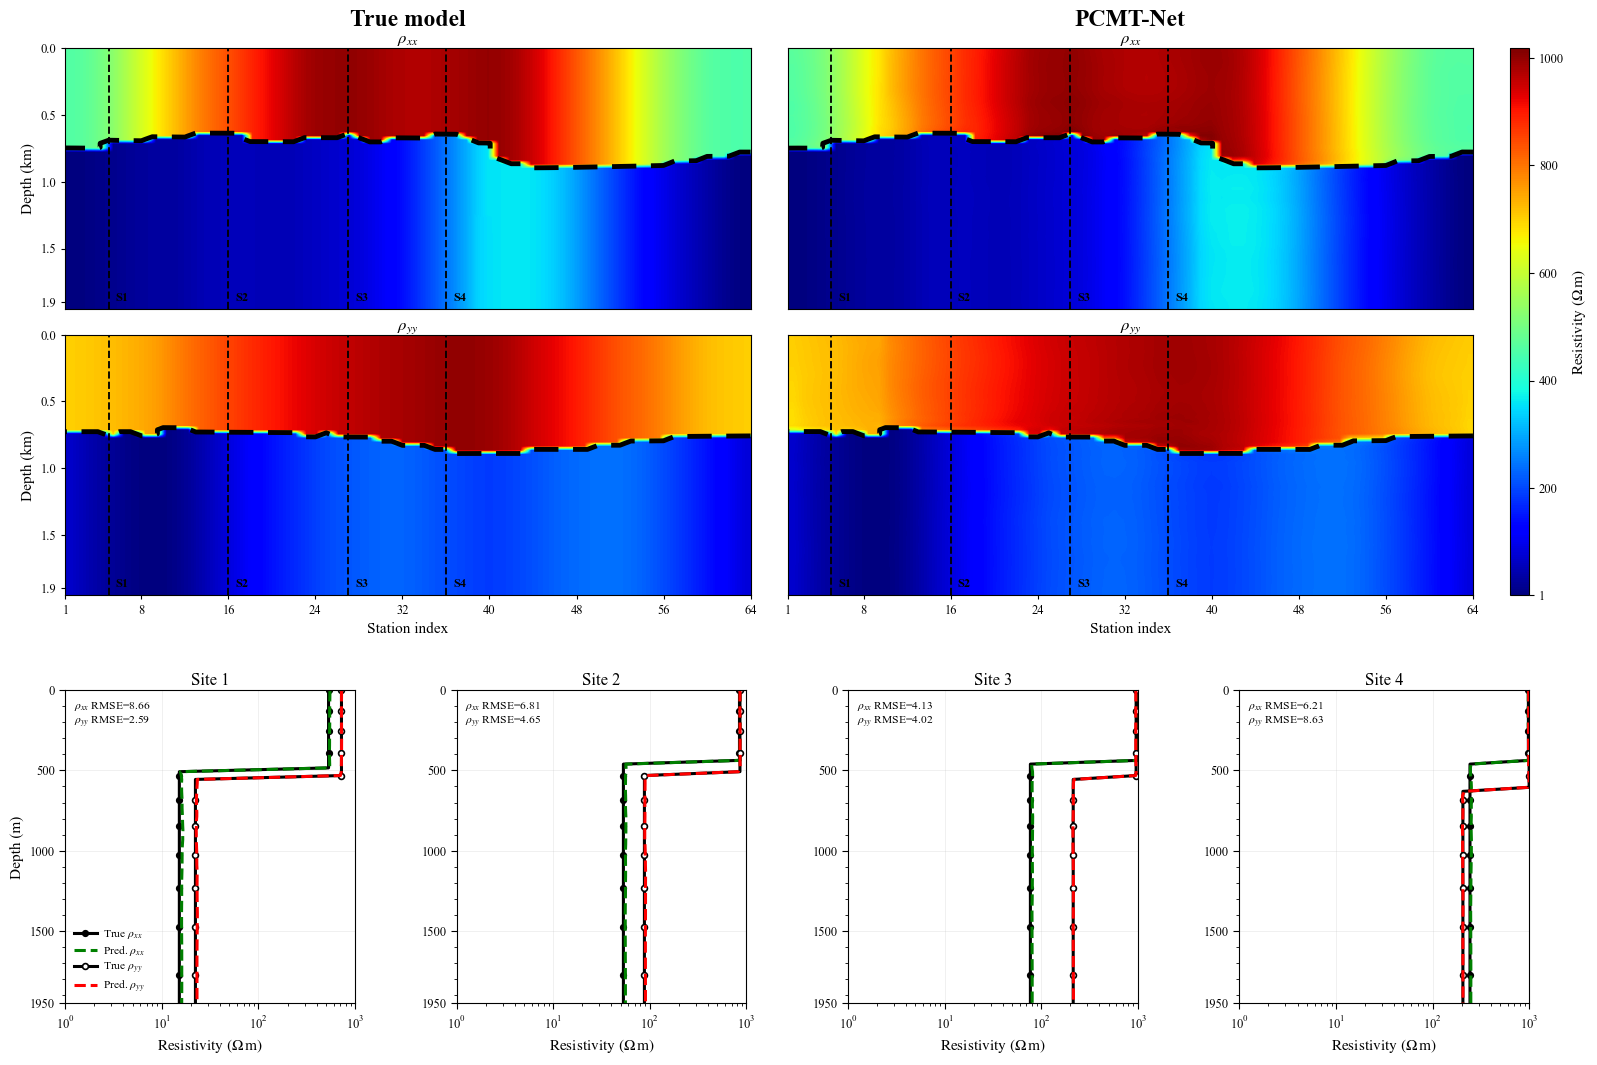

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import MultipleLocator


# ===== Torch denormalization version (supports CUDA tensors) =====
def log_minmax_denorm_torch(x_norm, log_min, log_max):
    return torch.exp(x_norm * (log_max - log_min) + log_min)


# ===== Add noise only to the right-side XFMR input =====
ALLOWED_NOISE_PCTS = {0, 1, 3, 5, 10}

def apply_right_noise(x, right_noise_pct=0, seed=None):
    if right_noise_pct not in ALLOWED_NOISE_PCTS:
        raise ValueError(f"right_noise_pct must be one of {sorted(ALLOWED_NOISE_PCTS)}")
    if right_noise_pct == 0:
        return x
    if seed is not None:
        torch.manual_seed(int(seed))
        np.random.seed(int(seed))
    ratio = right_noise_pct / 100.0
    x_noisy = x + ratio * torch.randn_like(x)
    return torch.clamp(x_noisy, 0.0, 1.0)


def pick_near_level(data2d, target=400.0, tol=0.0):
    """Use target exactly when tol=0; allow available values within target +/- tol when tol>0."""
    zmin = float(np.nanmin(data2d))
    zmax = float(np.nanmax(data2d))
    if zmin <= target <= zmax:
        return float(target)

    if tol <= 0:
        return None

    lo = target - tol
    hi = target + tol
    if zmin <= lo <= zmax:
        return float(lo)
    if zmin <= hi <= zmax:
        return float(hi)
    return None



def draw_upper_iso_contour(ax, data2d, level, ymax_km):
    """
    Overlay black, thick, sparse dashed contours on the upper-half heatmap.
    Use coordinates consistent with imshow(extent=[0, ncol-1, ymax_km, 0]) to avoid vertical offsets.
    """
    if level is None:
        return

    nz, nx = data2d.shape
    x = np.arange(nx)
    y = np.linspace(0.0, ymax_km, nz)
    Xg, Yg = np.meshgrid(x, y)

    cs = ax.contour(
        Xg, Yg, data2d,
        levels=[level],
        colors="#000000",
        linewidths=3.5,
        linestyles="--",   # Set dashed lines first
        alpha=1.0,
        zorder=8
    )

    # Matplotlib 3.8+: do not use cs.collections anymore
    dash_style = (0, (5, 3))  # Current desired dash density
    if hasattr(cs, "set_linestyle"):
        cs.set_linestyle(dash_style)
    elif hasattr(cs, "set_linestyles"):
        cs.set_linestyles([dash_style])



def plot_one_case(
    num,
    Y_all,
    user_cols,
    right_noise_pct=0,
    noise_seed=2026,
    max_sites=8,
    top_ratio=1.28,
    bottom_ratio=1.72,
    bottom_box_aspect=None,
    draw_upper_iso=False,
    iso_target=400.0,
    iso_tol=0.0
):
    start = num * 64
    end = start + 64

    T = X_norm[start:end]
    TT = Y_all[start:end]

    model_device = next(model.parameters()).device
    T_tensor = torch.tensor(T, dtype=torch.float32, device=model_device)

    if T_tensor.shape[-1] != 4:
        T_tensor = T_tensor.permute(0, 2, 1)

    T_for_pred = apply_right_noise(T_tensor, right_noise_pct=right_noise_pct, seed=noise_seed + int(num))

    with torch.no_grad():
        pred = model(T_for_pred)

    log_min = torch.tensor(Y_log_min, dtype=torch.float32, device=pred.device)
    log_max = torch.tensor(Y_log_max, dtype=torch.float32, device=pred.device)
    Y_rec_pre = log_minmax_denorm_torch(pred, log_min, log_max)

    X_p_raw = Y_rec_pre[:, :, 0].detach().cpu().numpy()
    Y_p_raw = Y_rec_pre[:, :, 1].detach().cpu().numpy()
    X_t_raw = TT[:, :, 0]
    Y_t_raw = TT[:, :, 1]

    X_p = X_p_raw.T
    Y_p = Y_p_raw.T
    X_t = X_t_raw.T
    Y_t = Y_t_raw.T

    sel = [int(x) for x in user_cols.split()]
    if len(sel) < max_sites:
        raise ValueError(f"At least {max_sites} column numbers must be provided")
    col_idx = np.array(sel[:max_sites]) - 1
    if np.any(col_idx < 0) or np.any(col_idx >= X_p.shape[1]):
        raise ValueError(f"Column number out of range; it should be between 1 and {X_p.shape[1]}")

    def build_depth():
        depth = np.zeros((64, 1))
        for i in range(63):
            depth[i + 1, 0] = 20 + 10 ** (0.026026 * i) + depth[i, 0]
        return depth.reshape(-1)

    depth_axis = build_depth()

    # plt.rcParams.update({
    #     "font.family": "sans-serif",
    #     "font.size": 10,
    #     "axes.titlesize": 12,
    #     "axes.labelsize": 11,
    #     "xtick.labelsize": 9,
    #     "ytick.labelsize": 9,
    #     "legend.fontsize": 8,
    #     "figure.facecolor": "white",
    #     "axes.facecolor": "white",
    #     "savefig.facecolor": "white",
    #     "axes.linewidth": 0.8
    # })

    plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.linewidth": 0.8
    })


    vmin = float(min(X_t.min(), Y_t.min(), X_p.min(), Y_p.min()))
    vmax = float(max(X_t.max(), Y_t.max(), X_p.max(), Y_p.max()))

    def mark_cols_and_labels(ax):
        for i, c in enumerate(col_idx):
            ax.axvline(c, color='k', ls='--', lw=1.4, alpha=0.95)
            ax.annotate(
                f"S{i+1}",
                xy=(c, 0.02),
                xycoords=ax.get_xaxis_transform(),
                xytext=(5, 0),
                textcoords='offset points',
                ha='left', va='bottom',
                fontsize=9, color='k', fontweight='bold',
                zorder=6
            )

    def style_profile_ax(ax):
        ax.set_xscale("log")
        ax.set_xlim(1, 1000)
        ax.set_ylim(0, 1950)
        ax.invert_yaxis()
        ax.set_yticks([0, 500, 1000, 1500, 1950])
        ax.yaxis.set_minor_locator(MultipleLocator(100))
        ax.tick_params(axis="both", which="major", length=4, width=0.8)
        ax.tick_params(axis="both", which="minor", length=2, width=0.6)
        ax.grid(True, which='major', alpha=0.22, lw=0.6)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    fig = plt.figure(figsize=(16, 11))
    outer = GridSpec(
        nrows=2, ncols=1, figure=fig,
        height_ratios=[top_ratio, bottom_ratio],
        hspace=0.20,
        left=0.055, right=0.97, top=0.95, bottom=0.075
    )

    top = GridSpecFromSubplotSpec(
        2, 3, subplot_spec=outer[0],
        width_ratios=[1, 1, 0.028],
        wspace=0.08,
        hspace=0.10
    )

    ax_xt = fig.add_subplot(top[0, 0])
    ax_yt = fig.add_subplot(top[1, 0])
    ax_xp = fig.add_subplot(top[0, 1])
    ax_yp = fig.add_subplot(top[1, 1])
    cax = fig.add_subplot(top[:, 2])

    nrow, ncol = X_t.shape
    ymax_km = depth_axis[-1] / 1000.0
    heat_extent = [0, ncol - 1, ymax_km, 0.0]
    yticks_km = [0.0, 0.5, 1.0, 1.5, 1.9]

    station_ticks = np.array([1, 8, 16, 24, 32, 40, 48, 56, 64])
    station_ticks = station_ticks[station_ticks <= ncol]
    station_pos = station_ticks - 1

    im1 = ax_xt.imshow(X_t, cmap='jet', aspect='auto', interpolation='bilinear',
                       vmin=vmin, vmax=vmax, extent=heat_extent)
    mark_cols_and_labels(ax_xt)
    ax_xt.set_title(r"$\rho_{xx}$", y=1.01, pad=2)

    im2 = ax_yt.imshow(Y_t, cmap='jet', aspect='auto', interpolation='bilinear',
                       vmin=vmin, vmax=vmax, extent=heat_extent)
    mark_cols_and_labels(ax_yt)
    ax_yt.set_title(r"$\rho_{yy}$", y=1.01, pad=2)

    im3 = ax_xp.imshow(X_p, cmap='jet', aspect='auto', interpolation='bilinear',
                       vmin=vmin, vmax=vmax, extent=heat_extent)
    mark_cols_and_labels(ax_xp)
    ax_xp.set_title(r"$\rho_{xx}$", y=1.01, pad=2)

    im4 = ax_yp.imshow(Y_p, cmap='jet', aspect='auto', interpolation='bilinear',
                       vmin=vmin, vmax=vmax, extent=heat_extent)
    mark_cols_and_labels(ax_yp)
    ax_yp.set_title(r"$\rho_{yy}$", y=1.01, pad=2)

    if draw_upper_iso:
        for ax, arr in [(ax_xt, X_t), (ax_yt, Y_t), (ax_xp, X_p), (ax_yp, Y_p)]:
            lv = pick_near_level(arr, target=iso_target, tol=iso_tol)
            draw_upper_iso_contour(ax, arr, lv, ymax_km)

    for ax in [ax_xt, ax_yt]:
        ax.set_ylabel("Depth (km)")
        ax.set_yticks(yticks_km)
        ax.tick_params(axis='y', which='major', length=3, width=0.8, direction='out')

    for ax in [ax_xp, ax_yp]:
        ax.set_yticks([])

    ax_xt.set_xticks([])
    ax_xp.set_xticks([])

    for ax in [ax_yt, ax_yp]:
        ax.set_xticks(station_pos)
        ax.set_xticklabels([str(v) for v in station_ticks])
        ax.set_xlabel("Station index")
        ax.tick_params(axis='x', which='major', length=3, width=0.8, direction='out')

    cbar = fig.colorbar(im4, cax=cax)
    vmin_now = float(im4.norm.vmin)
    ticks = [vmin_now, 200, 400, 600, 800, 1000]
    ticks = [t for t in ticks if t <= im4.norm.vmax]
    cbar.set_ticks(ticks)
    cbar.set_label(r"$\mathrm{Resistivity}\ (\Omega\,\mathrm{m})$")
    cbar.ax.tick_params(labelsize=9)

    left_center_x = 0.5 * (ax_xt.get_position().x0 + ax_xt.get_position().x1)
    right_center_x = 0.5 * (ax_xp.get_position().x0 + ax_xp.get_position().x1)
    header_y = min(0.995, max(ax_xt.get_position().y1, ax_xp.get_position().y1) + 0.016)

    fig.text(left_center_x, header_y, "True model",
             ha='center', va='bottom', fontsize=17, fontweight='bold')
    # right_title = "XFMR" if right_noise_pct == 0 else f"XFMR ({right_noise_pct}% noise)"
    right_title = "PCMT-Net" if right_noise_pct == 0 else f"PCMT-Net ({right_noise_pct}% noise)"

    fig.text(right_center_x, header_y, right_title,
             ha='center', va='bottom', fontsize=17, fontweight='bold')

    if max_sites == 4:
        bottom_rows, bottom_cols = 1, 4
        bottom = GridSpecFromSubplotSpec(
            bottom_rows, bottom_cols, subplot_spec=outer[1],
            wspace=0.35, hspace=0.0
        )
    else:
        bottom_rows, bottom_cols = 2, 4
        bottom = GridSpecFromSubplotSpec(
            bottom_rows, bottom_cols, subplot_spec=outer[1],
            wspace=0.28, hspace=0.20
        )

    axes = []
    for i in range(max_sites):
        ax = fig.add_subplot(bottom[i // bottom_cols, i % bottom_cols])
        if (bottom_box_aspect is not None) and hasattr(ax, "set_box_aspect"):
            ax.set_box_aspect(bottom_box_aspect)
        axes.append(ax)

    for i, (ax, c) in enumerate(zip(axes, col_idx)):
        xt = X_t[:, c]
        xp = X_p[:, c]
        yt = Y_t[:, c]
        yp = Y_p[:, c]

        ax.plot(xt, depth_axis, color='k', ls='-', lw=2.2,
                marker='o', ms=4.2, markevery=6, mfc='k', mec='k',
                label=r"True $\rho_{xx}$")
        ax.plot(xp, depth_axis, color='g', ls='--', lw=2.2,
                label=r"Pred. $\rho_{xx}$")
        ax.plot(yt, depth_axis, color='k', ls='-', lw=2.2,
                marker='o', ms=4.2, markevery=6, mfc='white', mec='k', mew=1.2,
                label=r"True $\rho_{yy}$")
        ax.plot(yp, depth_axis, color='r', ls='--', lw=2.2,
                label=r"Pred. $\rho_{yy}$")

        style_profile_ax(ax)
        ax.set_title(f"Site {i+1}", pad=4)

        rmse_xx = np.sqrt(np.mean((xp - xt) ** 2))
        rmse_yy = np.sqrt(np.mean((yp - yt) ** 2))
        ax.text(
            0.03, 0.97,
            f"$\\rho_{{xx}}$ RMSE={rmse_xx:.2f}\n$\\rho_{{yy}}$ RMSE={rmse_yy:.2f}",
            transform=ax.transAxes,
            ha='left', va='top',
            multialignment='left',
            fontsize=8.3,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.55, pad=1.0)
        )

        if i % bottom_cols == 0:
            ax.set_ylabel("Depth (m)")
        else:
            ax.set_ylabel("")

        if i // bottom_cols == bottom_rows - 1:
            ax.set_xlabel(r"$\mathrm{Resistivity}\ (\Omega\,\mathrm{m})$")
        else:
            ax.set_xlabel("")

        if i == 0:
            leg = ax.legend(
                loc='lower left',
                fontsize=8.3,
                frameon=True,
                fancybox=True,
                framealpha=0.55,
                borderpad=0.25,
                handlelength=2.0,
                handletextpad=0.5,
                labelspacing=0.25
            )
            leg.get_frame().set_facecolor('white')
            leg.get_frame().set_edgecolor('none')


    plt.savefig(f"Figure{num}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"Figure{num}.svg", bbox_inches="tight")

    plt.show()



# ===== Draw twice consecutively =====
Y_all = np.load('Y_all.npy')
Y_all = np.transpose(Y_all, (0, 2, 1))

YBZ = 4253 - 4000
user_cols = "5 16 27 36 42 49 55 61"
right_noise_pct = 0

print(f"Plot #1: num={YBZ}, right_noise_pct={right_noise_pct}%")
plot_one_case(
    YBZ, Y_all, user_cols,
    right_noise_pct=right_noise_pct,
    max_sites=8,
    top_ratio=1.28,
    bottom_ratio=1.72,
    bottom_box_aspect=None,
    draw_upper_iso=False
)

print(f"Plot #2: num={YBZ + 4000}, right_noise_pct={right_noise_pct}% (S1-S4 only)")
plot_one_case(
    YBZ + 4000, Y_all, user_cols,
    right_noise_pct=right_noise_pct,
    max_sites=4,
    top_ratio=1.75,
    bottom_ratio=1.05,
    bottom_box_aspect=1.08,
    draw_upper_iso=True,
    iso_target=400.0,  # Specify 400
    iso_tol=0.0        # Use exactly 400; do not automatically switch values
)


In [ ]:
# ===== A3: Full-dataset RMSE Distribution (4 subplots) =====
# Statistical target: every sample in the full (X_all, Y_all) dataset (sample-wise RMSE)
# Groups: curve-like(rho_xx), curve-like(rho_yy), layered(rho_xx), layered(rho_yy)

import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# 0) Read data; load from files if not already in memory
# -----------------------------
if "model" not in globals():
    raise RuntimeError("model was not detected; please run the model-loading cell first.")

if "X_all" not in globals():
    X_all = np.load("X_all.npy")
if "Y_all" not in globals():
    Y_all = np.load("Y_all.npy")

X_all = np.asarray(X_all)
Y_all = np.asarray(Y_all)

def to_nlc(arr, expected_c, name):
    """Convert to (N, L, C), supporting both (N, C, L) and (N, L, C)."""
    if arr.ndim != 3:
        raise ValueError(f"{name} must be 3D; current shape={arr.shape}")
    n, a, b = arr.shape
    if a == expected_c and b != expected_c:
        return np.transpose(arr, (0, 2, 1))  # (N,C,L)->(N,L,C)
    if b == expected_c and a != expected_c:
        return arr
    if min(a, b) == expected_c:
        return np.transpose(arr, (0, 2, 1)) if a == expected_c else arr
    raise ValueError(f"{name} dimensions cannot be recognized as (N,C,L)/(N,L,C); shape={arr.shape}")

X_phys = to_nlc(X_all, expected_c=4, name="X_all")   # (N,L,4)
Y_phys = to_nlc(Y_all, expected_c=2, name="Y_all")   # (N,L,2)

eps = 1e-12
X_log = np.log(np.clip(X_phys, eps, None))
Y_log = np.log(np.clip(Y_phys, eps, None))

X_log_min, X_log_max = X_log.min(), X_log.max()
Y_log_min, Y_log_max = Y_log.min(), Y_log.max()

X_norm = (X_log - X_log_min) / (X_log_max - X_log_min)  # (N,L,4)
N = X_norm.shape[0]

print(f"[A3] X_norm shape={X_norm.shape}, Y_phys shape={Y_phys.shape}, total samples={N}")

# -----------------------------
# 1) Sample-wise RMSE calculation for all samples (clean)
# -----------------------------
def compute_samplewise_rmse(model, X_norm_arr, Y_true_phys_arr, y_log_min, y_log_max, batch_size=4096):
    device = next(model.parameters()).device
    n = X_norm_arr.shape[0]

    rmse_xx = np.empty(n, dtype=np.float64)
    rmse_yy = np.empty(n, dtype=np.float64)

    y_min_t = torch.tensor(float(y_log_min), dtype=torch.float32, device=device)
    y_max_t = torch.tensor(float(y_log_max), dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        for s in range(0, n, batch_size):
            e = min(s + batch_size, n)

            xb = torch.tensor(X_norm_arr[s:e], dtype=torch.float32, device=device)      # (B,L,4)
            yb = torch.tensor(Y_true_phys_arr[s:e], dtype=torch.float32, device=device)  # (B,L,2)

            pred_norm = model(xb)
            # Support either (B,L,2) or (B,2,L)
            if pred_norm.ndim != 3:
                raise ValueError(f"Unexpected model output dimensions: {pred_norm.shape}")
            if pred_norm.shape[-1] == 2:
                pred_nlc = pred_norm
            elif pred_norm.shape[1] == 2:
                pred_nlc = pred_norm.permute(0, 2, 1)
            else:
                raise ValueError(f"Cannot recognize the channel dimension of the model output: {pred_norm.shape}")

            pred_phys = torch.exp(pred_nlc * (y_max_t - y_min_t) + y_min_t)

            err_xx = pred_phys[:, :, 0] - yb[:, :, 0]
            err_yy = pred_phys[:, :, 1] - yb[:, :, 1]

            rmse_xx[s:e] = torch.sqrt(torch.mean(err_xx ** 2, dim=1)).cpu().numpy()
            rmse_yy[s:e] = torch.sqrt(torch.mean(err_yy ** 2, dim=1)).cpu().numpy()

    return rmse_xx, rmse_yy

rmse_xx_all, rmse_yy_all = compute_samplewise_rmse(
    model=model,
    X_norm_arr=X_norm,
    Y_true_phys_arr=Y_phys,
    y_log_min=Y_log_min,
    y_log_max=Y_log_max,
    batch_size=4096
)

# -----------------------------
# 2) Sample type split (first half / second half)
# Set curve_first=False if the order is reversed
# -----------------------------
curve_first = True
if N % 2 != 0:
    raise ValueError(f"N={N} is not even, so it cannot be split into first and second halves.")

half = N // 2
if curve_first:
    curve_idx = slice(0, half)
    layer_idx = slice(half, N)
else:
    curve_idx = slice(half, N)
    layer_idx = slice(0, half)

curve_xx = rmse_xx_all[curve_idx]
curve_yy = rmse_yy_all[curve_idx]
layer_xx = rmse_xx_all[layer_idx]
layer_yy = rmse_yy_all[layer_idx]

# -----------------------------
# 3) Plot: 2x2 normalized percentage histograms + smooth curves
# -----------------------------
def percent_hist_and_smooth(values, bins, sigma_bins=1.2):
    counts, edges = np.histogram(values, bins=bins)
    pct = counts / max(1, counts.sum()) * 100.0
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Simple Gaussian convolution smoothing without relying on scipy
    radius = int(np.ceil(3 * sigma_bins))
    x = np.arange(-radius, radius + 1)
    k = np.exp(-0.5 * (x / sigma_bins) ** 2)
    k /= k.sum()
    smooth = np.convolve(pct, k, mode="same")
    return centers, pct, smooth

groups = [
    ("curve-like ($\\rho_{xx}$)", curve_xx, "#2F6DB3", 0.62, ""),
    ("curve-like ($\\rho_{yy}$)", curve_yy, "#2F6DB3", 0.44, "//"),
    ("layered ($\\rho_{xx}$)",    layer_xx, "#D27C2C", 0.62, ""),
    ("layered ($\\rho_{yy}$)",    layer_yy, "#D27C2C", 0.44, "//"),
]

all_vals = np.concatenate([g[1] for g in groups])
x_min = 0.0
x_max = float(np.max(all_vals))
n_bins = 48
bins = np.linspace(x_min, x_max, n_bins + 1)

stats = []
for title, arr, color, alpha, hatch in groups:
    centers, pct, smooth = percent_hist_and_smooth(arr, bins, sigma_bins=1.2)
    stats.append((title, centers, pct, smooth, color, alpha, hatch))

y_max = max(float(np.max(np.r_[pct, smooth])) for _, _, pct, smooth, _, _, _ in stats) * 1.12

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.9,
})

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9), sharex=True, sharey=True)
axes = axes.ravel()

bar_w = (bins[1] - bins[0]) * 0.95
for ax, (title, centers, pct, smooth, color, alpha, hatch) in zip(axes, stats):
    ax.bar(
        centers, pct, width=bar_w, align="center",
        color=color, alpha=alpha, edgecolor="white", linewidth=0.35, hatch=hatch
    )
    ax.plot(centers, smooth, color=color, linewidth=2.0)
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max)
    ax.grid(True, linestyle="--", alpha=0.25)

for ax in axes[2:]:
    ax.set_xlabel("RMSE")
for ax in axes[::2]:
    ax.set_ylabel("Percentage (%)")

# fig.suptitle("A3. RMSE Distribution on Full Dataset (All Samples)", fontsize=14, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# -----------------------------
# 4) Optional: print summary
# -----------------------------
def summary(name, arr):
    q1, q2, q3 = np.percentile(arr, [25, 50, 75])
    print(f"{name:24s} | mean={arr.mean():.6f} | median={q2:.6f} | IQR={(q3-q1):.6f}")

# print("\n[A3 Summary] Full-dataset sample-wise RMSE")
summary("curve-like rho_xx", curve_xx)
summary("curve-like rho_yy", curve_yy)
summary("layered rho_xx", layer_xx)
summary("layered rho_yy", layer_yy)


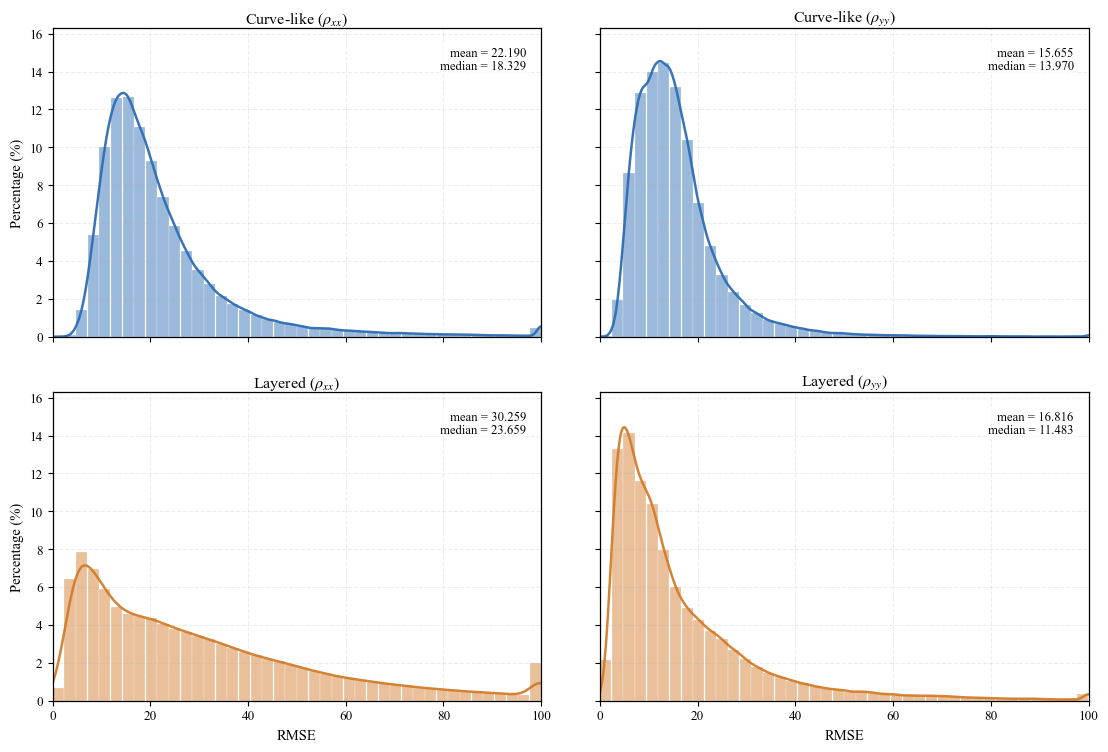

In [5]:
# ===== Experiment A: Full-dataset RMSE distribution plot (2x2, final style) =====
# Notes:
# 1) The statistical target is all samples in the full (X_all, Y_all) dataset (sample-wise RMSE)
# 2) Four subplots: Curve-like(rho_xx), Curve-like(rho_yy), Layered(rho_xx), Layered(rho_yy)
# 3) No overall title; the figure caption is provided in the main text

import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# 0) Data and model checks
# -----------------------------
if "model" not in globals():
    raise RuntimeError("model was not detected; please run the model-loading cell first.")

if "X_all" not in globals():
    X_all = np.load("X_all.npy")
if "Y_all" not in globals():
    Y_all = np.load("Y_all.npy")

X_all = np.asarray(X_all)
Y_all = np.asarray(Y_all)

def to_nlc(arr, expected_c, name):
    # Convert to (N, L, C), supporting both (N,C,L) and (N,L,C)
    if arr.ndim != 3:
        raise ValueError(f"{name} must be 3D; current shape={arr.shape}")
    _, a, b = arr.shape
    if a == expected_c and b != expected_c:
        return np.transpose(arr, (0, 2, 1))
    if b == expected_c and a != expected_c:
        return arr
    if min(a, b) == expected_c:
        return np.transpose(arr, (0, 2, 1)) if a == expected_c else arr
    raise ValueError(f"{name} dimensions cannot be recognized; shape={arr.shape}")

X_phys = to_nlc(X_all, expected_c=4, name="X_all")
Y_phys = to_nlc(Y_all, expected_c=2, name="Y_all")

eps = 1e-12
X_log = np.log(np.clip(X_phys, eps, None))
Y_log = np.log(np.clip(Y_phys, eps, None))

X_norm = (X_log - X_log.min()) / (X_log.max() - X_log.min())
Y_log_min, Y_log_max = Y_log.min(), Y_log.max()

N = X_norm.shape[0]

# -----------------------------
# 1) Sample-wise RMSE for all samples (rho_xx / rho_yy)
# -----------------------------
def compute_samplewise_rmse(model, X_norm_arr, Y_true_phys_arr, y_log_min, y_log_max, batch_size=4096):
    device = next(model.parameters()).device
    n = X_norm_arr.shape[0]

    rmse_xx = np.empty(n, dtype=np.float64)
    rmse_yy = np.empty(n, dtype=np.float64)

    y_min_t = torch.tensor(float(y_log_min), dtype=torch.float32, device=device)
    y_max_t = torch.tensor(float(y_log_max), dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        for s in range(0, n, batch_size):
            e = min(s + batch_size, n)

            xb = torch.tensor(X_norm_arr[s:e], dtype=torch.float32, device=device)      # (B,L,4)
            yb = torch.tensor(Y_true_phys_arr[s:e], dtype=torch.float32, device=device)  # (B,L,2)

            pred_norm = model(xb)
            if pred_norm.ndim != 3:
                raise ValueError(f"Unexpected model output dimensions: {pred_norm.shape}")

            # Support (B,L,2) / (B,2,L)
            if pred_norm.shape[-1] == 2:
                pred_nlc = pred_norm
            elif pred_norm.shape[1] == 2:
                pred_nlc = pred_norm.permute(0, 2, 1)
            else:
                raise ValueError(f"Cannot recognize the model output shape: {pred_norm.shape}")

            pred_phys = torch.exp(pred_nlc * (y_max_t - y_min_t) + y_min_t)

            err_xx = pred_phys[:, :, 0] - yb[:, :, 0]
            err_yy = pred_phys[:, :, 1] - yb[:, :, 1]

            rmse_xx[s:e] = torch.sqrt(torch.mean(err_xx ** 2, dim=1)).cpu().numpy()
            rmse_yy[s:e] = torch.sqrt(torch.mean(err_yy ** 2, dim=1)).cpu().numpy()

    return rmse_xx, rmse_yy

rmse_xx_all, rmse_yy_all = compute_samplewise_rmse(
    model=model,
    X_norm_arr=X_norm,
    Y_true_phys_arr=Y_phys,
    y_log_min=Y_log_min,
    y_log_max=Y_log_max,
    batch_size=4096
)

# -----------------------------
# 2) Sample type split (first half / second half)
# Set curve_first=False if the order is reversed
# -----------------------------
curve_first = True
if N % 2 != 0:
    raise ValueError(f"N={N} is not even, so it cannot be split into first and second halves.")

half = N // 2
if curve_first:
    curve_idx = slice(0, half)
    layer_idx = slice(half, N)
else:
    curve_idx = slice(half, N)
    layer_idx = slice(0, half)

curve_xx = rmse_xx_all[curve_idx]
curve_yy = rmse_yy_all[curve_idx]
layer_xx = rmse_xx_all[layer_idx]
layer_yy = rmse_yy_all[layer_idx]

# -----------------------------
# 3) Plotting parameters: unified x range and bins
# -----------------------------
all_vals = np.concatenate([curve_xx, curve_yy, layer_xx, layer_yy])

# Prefer 0-120; tighten to 0-100 if the main distribution is more concentrated
# Use the 99th percentile to judge the main interval
x_max = 120.0
if np.percentile(all_vals, 99.0) <= 100.0:
    x_max = 100.0

x_min = 0.0
n_bins = 42
bins = np.linspace(x_min, x_max, n_bins + 1)
bin_w = bins[1] - bins[0]
centers = 0.5 * (bins[:-1] + bins[1:])

def hist_percent(values, bins, x_max):
    # To ensure the total percentage is 100%, clip the long tail into the last bin for visualization
    v = np.clip(values, bins[0], x_max)
    cnt, _ = np.histogram(v, bins=bins)
    pct = cnt / len(values) * 100.0
    return pct

def kde_percent(values, x_grid, bin_width, x_max):
    # Pure NumPy KDE; output is per-bin percentage comparable with the histogram
    v = np.clip(values.astype(float), 0.0, x_max)
    n = len(v)
    if n < 2:
        return np.zeros_like(x_grid)

    std = np.std(v, ddof=1)
    iqr = np.subtract(*np.percentile(v, [75, 25]))
    sigma = min(std, iqr / 1.34) if iqr > 0 else std
    if sigma <= 1e-12:
        sigma = max(std, 1e-6)

    bw = 1.06 * sigma * (n ** (-1.0 / 5.0))
    bw = max(bw, 1e-3)

    z = (x_grid[None, :] - v[:, None]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=0) / (n * bw * np.sqrt(2.0 * np.pi))
    pct_per_bin = dens * bin_width * 100.0
    return pct_per_bin

groups = [
    (r"Curve-like ($\rho_{xx}$)", curve_xx, "#2F6DB3"),
    (r"Curve-like ($\rho_{yy}$)", curve_yy, "#2F6DB3"),
    (r"Layered ($\rho_{xx}$)",    layer_xx, "#D27C2C"),
    (r"Layered ($\rho_{yy}$)",    layer_yy, "#D27C2C"),
]

x_grid = np.linspace(x_min, x_max, 600)
plot_data = []
for title, arr, color in groups:
    hp = hist_percent(arr, bins, x_max)
    kd = kde_percent(arr, x_grid, bin_w, x_max)
    plot_data.append((title, arr, color, hp, kd))

y_max = max(max(d[3].max(), d[4].max()) for d in plot_data) * 1.12

# -----------------------------
# 4) 2x2 plot (compact version)
# -----------------------------
# plt.rcParams.update({
#     "font.family": "sans-serif",
#     "font.size": 10.5,
#     "axes.titlesize": 11.5,
#     "axes.labelsize": 10.5,
#     "xtick.labelsize": 9.5,
#     "ytick.labelsize": 9.5,
#     "axes.linewidth": 0.9
# })

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 10.5,
    "axes.titlesize": 11.5,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "axes.linewidth": 0.9
})


fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.6), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (title, arr, color, hp, kd) in zip(axes, plot_data):
    ax.bar(
        centers, hp, width=bin_w * 0.96,
        color=color, alpha=0.48, edgecolor="white", linewidth=0.35
    )
    ax.plot(x_grid, kd, color=color, linewidth=1.8, alpha=0.95)

    ax.set_title(title, pad=4)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max)
    ax.grid(True, linestyle="--", alpha=0.22)

    mean_v = np.mean(arr)
    med_v = np.median(arr)
    ax.text(
        0.97, 0.94,
        f"mean = {mean_v:.3f}\nmedian = {med_v:.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9.2,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.70, pad=1.4)
    )

for ax in axes[2:]:
    ax.set_xlabel("RMSE")
for ax in axes[::2]:
    ax.set_ylabel("Percentage (%)")

# Compact layout without an overall title
fig.subplots_adjust(left=0.07, right=0.995, bottom=0.08, top=0.965, wspace=0.12, hspace=0.18)

# Save figures
plt.savefig("F11.png", dpi=600, bbox_inches="tight")
plt.savefig("F11.svg", bbox_inches="tight")
plt.show()
